# Detecting mastitis in dairy cows

# Step 1: Import Libraries

In [19]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from PIL import Image
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


# Step 2: Data Loading

In [20]:
data_dir = '/kaggle/input/mastitis-disease-detection/Data'  # dataset root

# Transforms
train_tfms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
val_test_tfms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# Load dataset (all images first)
full_ds = datasets.ImageFolder(data_dir, transform=train_tfms)

# Split into train/val/test (70/15/15)
n = len(full_ds)
train_size = int(0.7 * n)
val_size   = int(0.15 * n)
test_size  = n - train_size - val_size
train_ds, val_ds, test_ds = random_split(full_ds, [train_size,val_size,test_size])

# Assign transforms
val_ds.dataset.transform = val_test_tfms
test_ds.dataset.transform = val_test_tfms

# DataLoaders
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=16)
test_loader  = DataLoader(test_ds, batch_size=16)

class_names = full_ds.classes
print("Classes:", class_names)
print(f"Samples -> Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")

Classes: ['mastitis', 'normal teats']
Samples -> Train: 125, Val: 27, Test: 28


# Step 3: Data Visualization

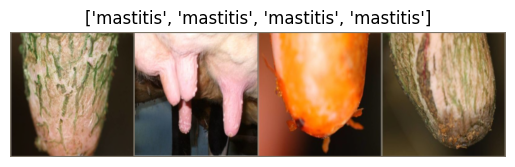

In [22]:
def imshow(inp, title=None):
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title: plt.title(title)
    plt.axis('off')

inputs, classes_idx = next(iter(train_loader))
out = torchvision.utils.make_grid(inputs[:4])
imshow(out, title=[class_names[x] for x in classes_idx[:4]])

# Step 4: Model Selection (Transfer Learning)

In [23]:
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
for param in model.parameters():
    param.requires_grad = False
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(class_names))
model = model.to(device)
print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 167MB/s] 


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

# Step 5: Loss and Optimizer

In [25]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

# Step 6: Training with Early Stopping

Epoch 1/15, Train Loss: 0.3523, Val Loss: 0.1254
Epoch 2/15, Train Loss: 0.2989, Val Loss: 0.1291
Epoch 3/15, Train Loss: 0.2756, Val Loss: 0.1551
Epoch 4/15, Train Loss: 0.2297, Val Loss: 0.1602
Epoch 5/15, Train Loss: 0.1998, Val Loss: 0.1286
Epoch 6/15, Train Loss: 0.1776, Val Loss: 0.1453
Early stopping triggered


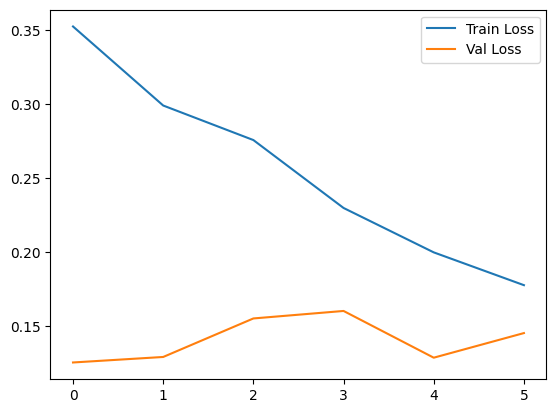

In [26]:
class EarlyStopping:
    def __init__(self, patience=5, delta=0):
        self.patience = patience
        self.delta = delta
        self.best_loss = None
        self.counter = 0
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

early_stopping = EarlyStopping(patience=5)

num_epochs = 15
train_losses, val_losses = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    # Validation
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
    val_loss = running_loss / len(val_loader)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    early_stopping(val_loss)
    if early_stopping.early_stop:
        print("Early stopping triggered")
        break

# Plot losses
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.show()

# Step 7: Evaluation on Test Set

Classification Report:
               precision    recall  f1-score   support

    mastitis       0.96      1.00      0.98        27
normal teats       0.00      0.00      0.00         1

    accuracy                           0.96        28
   macro avg       0.48      0.50      0.49        28
weighted avg       0.93      0.96      0.95        28



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


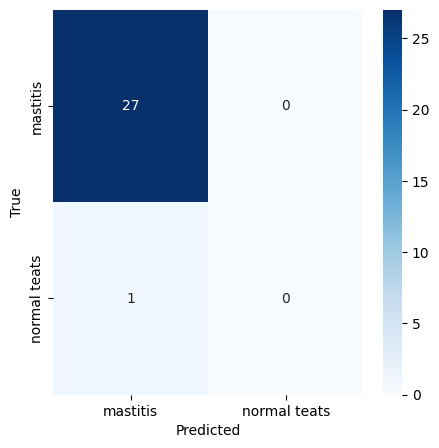

In [27]:
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print("Classification Report:\n", classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Step 8: Model Inference (random image from dataset)

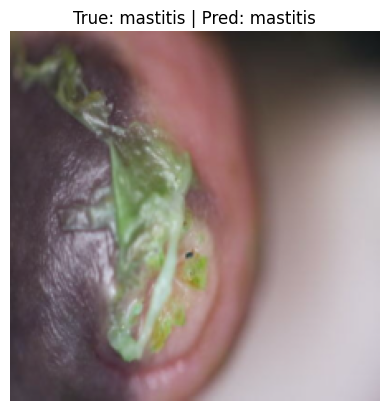

In [28]:
def predict_random_image(dataset, model, class_names):
    model.eval()
    idx = random.randint(0, len(dataset)-1)
    image, label = dataset[idx]
    plt.imshow(image.permute(1, 2, 0).numpy() * 0.229 + 0.485)  # undo normalization approx
    plt.axis("off")
    with torch.no_grad():
        image = image.unsqueeze(0).to(device)
        outputs = model(image)
        _, pred = torch.max(outputs, 1)
    plt.title(f"True: {class_names[label]} | Pred: {class_names[pred.item()]}")
    plt.show()

predict_random_image(test_ds, model, class_names)

# Step 9: Save Model

In [29]:
torch.save(model.state_dict(), "mastitis_resnet18.pth")
print("Model saved as mastitis_resnet18.pth")

Model saved as mastitis_resnet18.pth
